### Neuron

**Definition:** The neuron is a function $f:\mathbb{R}^n\rightarrow\mathbb{R}$ defined as 

$$f(\mathbf{x})=\phi(\mathbf{w}\cdot\bar{\mathbf{x}})$$

where

 - $\mathbf{x}\in\mathbb{R}^n$ is the input vector
 - $\bar{\mathbf{x}}=\begin{bmatrix}x\\1\end{bmatrix}\in\mathbb{R}^{n+1}$ is the input vector with a 1 for the bias term
 - $\mathbf{w}\in\mathbb{R}^{n+1}$ is the weight vector with a bias term
 - $\phi:\mathbb{R}\rightarrow\mathbb{R}$ is the activation function

**Non-linear Activation:** The Universal Approximation Theorem states, a feedforward neural network with a single hidden layer containing a finite number of neurons and a non-linear activation function can approximate any continuous function on compact subsets of $\mathbb{R}^n$.

### Single Layer Neural Network

**Definition:** A single layer neural network is a vector-valued function $f:\mathbb{R}^n\rightarrow\mathbb{R}^m$ defined by

$$f(\mathbf{x})=\phi(\mathbf{W}\bar{\mathbf{x}})$$

where

 - $\mathbf{x}\in\mathbb{R}^n$ is the input vector          w
 - $\bar{\mathbf{x}}=\begin{bmatrix}x\\1\end{bmatrix}\in\mathbb{R}^{n+1}$ is the input vector augmented with a 1 for the bias term,
 - $\mathbf{W}\in\mathbb{R}^{m\times(n+1)}$ is the weight matrix, where each row corresponds to the weights (including bias) for one neuron,
 - $\phi:\mathbb{R}\rightarrow\mathbb{R}$ is a scalar activation function, extended to vectors in $\mathbb{R}^m$ by elementwise application of the dot product.

### Multi Layer Neural Network


**Definition:** A multi layer neural network is a vector-valued function $f:\mathbb{R}^n\rightarrow\mathbb{R}^m$ defined as a composition of affine transformations and activation functions over $L$ layers:

$$f(\mathbf{x})=\phi^{(L)}(\mathbf{W}^{(L)}\cdot\phi^{(L-1)}(\mathbf{W}^{(L-1)}\ldots\phi^{(1)}(\mathbf{W}^{(1)}\cdot\bar{\mathbf{x}})\ldots))$$

where

 - $\mathbf{x}\in\mathbb{R}^n$ is the input vector.
 - $\bar{\mathbf{x}}=\begin{bmatrix}x\\1\end{bmatrix}\in\mathbb{R}^{n+1}$ is the input augmented with a bias term.
 - $L\in\mathbb{N}$ is the total number of layers.
 - $\phi^{(\ell)}:\mathbb{R}^{d_{\ell}}\rightarrow\mathbb{R}^{d_{\ell}}$ is an activation function applied component wise.
 - $\mathbf{W}^{(\ell)}\in\mathbb{R}^{d_{\ell}\times(d_{\ell-1}+1)}$ is the weight matrix of the $\ell$-th layer, where $d_0=n$ and $d_L=m$.



**Layer-wise Representation:** 

$$h^{(0)}=\mathbf{x}$$

$$\begin{align*}
\mathbf{z}^{(\ell)}&=\mathbf{W}^{(\ell)}\cdot\bar{\mathbf{h}}^{(\ell-1)}&\text{pre-activation}\\
\mathbf{h}^{(\ell)}&=\phi^{(\ell)}(\mathbf{z}^{(\ell)})&\text{post-activation}
\end{align*}$$

### Backpropagation

**Definition:** A highly efficient algorithm for indirectly computing the gradient of the loss function with respect to all the weights in a neural network by applying the chain rule in a structured, recursive way.

**Algorithm:**

*Forward pass:* Compute $\mathbf{z}^{(\ell)}, \mathbf{h}^{(\ell)}$ for $\ell = 1, \ldots, L$:

$$\mathbf{z}^{(\ell)} = \mathbf{W}^{(\ell)} \bar{\mathbf{h}}^{(\ell-1)}, \qquad \mathbf{h}^{(\ell)} = \phi^{(\ell)}(\mathbf{z}^{(\ell)})$$

*Backward pass:*

1. Initialize output error signal:
$$\boldsymbol{\delta}^{(L)} = \nabla_{\mathbf{h}^{(L)}} \mathcal{L} \circ \phi'^{(L)}(\mathbf{z}^{(L)})$$

2. Propagate error backwards for $\ell = L-1, \ldots, 1$:
$$\boldsymbol{\delta}^{(\ell)} = \left((\mathbf{W}^{(\ell+1)})^\top \boldsymbol{\delta}^{(\ell+1)}\right) \circ \phi'^{(\ell)}(\mathbf{z}^{(\ell)})$$

3. Compute weight gradients at each layer:
$$\nabla_{\mathbf{W}^{(\ell)}} \mathcal{L} = \boldsymbol{\delta}^{(\ell)} \left(\bar{\mathbf{h}}^{(\ell-1)}\right)^\top$$

4. Update weights via gradient descent:
$$\mathbf{W}^{(\ell)} \leftarrow \mathbf{W}^{(\ell)} - \eta \, \nabla_{\mathbf{W}^{(\ell)}} \mathcal{L}$$

---

**Derivation:**

Define the **error signal** at layer $\ell$ as the gradient of the loss with respect to the pre-activation:

$$\delta^{(\ell)}_j = \frac{\partial \mathcal{L}}{\partial z^{(\ell)}_j}$$

**Output layer** $(\ell = L)$: Apply the chain rule through the activation:

$$\delta^{(L)}_j = \frac{\partial \mathcal{L}}{\partial h^{(L)}_j} \cdot \frac{\partial h^{(L)}_j}{\partial z^{(L)}_j} = \frac{\partial \mathcal{L}}{\partial h^{(L)}_j} \cdot \phi'^{(L)}(z^{(L)}_j)$$

In matrix form: $\boldsymbol{\delta}^{(L)} = \nabla_{\mathbf{h}^{(L)}} \mathcal{L} \circ \phi'^{(L)}(\mathbf{z}^{(L)})$.

**Hidden layers** $(\ell < L)$: Each pre-activation $z^{(\ell)}_j$ influences $\mathcal{L}$ through all neurons in the next layer. By the chain rule:

$$\delta^{(\ell)}_j = \frac{\partial \mathcal{L}}{\partial z^{(\ell)}_j} = \sum_k \frac{\partial \mathcal{L}}{\partial z^{(\ell+1)}_k} \cdot \frac{\partial z^{(\ell+1)}_k}{\partial z^{(\ell)}_j}$$

Since $z^{(\ell+1)}_k = \sum_j W^{(\ell+1)}_{kj}\, h^{(\ell)}_j + b^{(\ell+1)}_k$ and $h^{(\ell)}_j = \phi^{(\ell)}(z^{(\ell)}_j)$:

$$\frac{\partial z^{(\ell+1)}_k}{\partial z^{(\ell)}_j} = W^{(\ell+1)}_{kj} \cdot \phi'^{(\ell)}(z^{(\ell)}_j)$$

Substituting:

$$\delta^{(\ell)}_j = \phi'^{(\ell)}(z^{(\ell)}_j) \sum_k W^{(\ell+1)}_{kj}\, \delta^{(\ell+1)}_k$$

In matrix form:

$$\boldsymbol{\delta}^{(\ell)} = \left((\mathbf{W}^{(\ell+1)})^\top \boldsymbol{\delta}^{(\ell+1)}\right) \circ \phi'^{(\ell)}(\mathbf{z}^{(\ell)})$$

**Weight gradients:** Each weight $W^{(\ell)}_{jk}$ only affects $\mathcal{L}$ through $z^{(\ell)}_j$, since $z^{(\ell)}_j = \sum_k W^{(\ell)}_{jk}\, \bar{h}^{(\ell-1)}_k$:

$$\frac{\partial \mathcal{L}}{\partial W^{(\ell)}_{jk}} = \frac{\partial \mathcal{L}}{\partial z^{(\ell)}_j} \cdot \frac{\partial z^{(\ell)}_j}{\partial W^{(\ell)}_{jk}} = \delta^{(\ell)}_j \cdot \bar{h}^{(\ell-1)}_k$$

In matrix form (outer product):

$$\nabla_{\mathbf{W}^{(\ell)}} \mathcal{L} = \boldsymbol{\delta}^{(\ell)} \left(\bar{\mathbf{h}}^{(\ell-1)}\right)^\top$$

**Complexity:** Each forward and backward pass costs $O\!\left(\sum_\ell d_\ell \cdot d_{\ell-1}\right)$ — the same order as a single forward pass. This is exponentially cheaper than naïve finite-difference gradient estimation, which would require one forward pass per parameter.

# Recurrent Neural Networks (RNNs)

## Motivation

Feedforward networks map a fixed-size input to a fixed-size output with no memory of previous inputs. Sequential data — text, audio, time series, video — has an inherent temporal structure: the prediction at time $t$ should depend on the history $x_1, \ldots, x_{t-1}$. RNNs address this by maintaining a **hidden state** that is updated at each time step.

---

## Vanilla RNN

The hidden state $\mathbf{h}_t \in \mathbb{R}^d$ evolves as:

$$\mathbf{h}_t = \phi\left(\mathbf{W}_h \mathbf{h}_{t-1} + \mathbf{W}_x \mathbf{x}_t + \mathbf{b}\right)$$

$$\mathbf{y}_t = \mathbf{W}_y \mathbf{h}_t + \mathbf{b}_y$$

where:
- $\mathbf{x}_t \in \mathbb{R}^n$ — input at time $t$
- $\mathbf{h}_{t-1}$ — previous hidden state (initialized to $\mathbf{0}$)
- $\mathbf{W}_h \in \mathbb{R}^{d \times d}$, $\mathbf{W}_x \in \mathbb{R}^{d \times n}$ — recurrent and input weight matrices
- $\phi$ — nonlinearity (typically $\tanh$)

The same weights $\mathbf{W}_h, \mathbf{W}_x$ are shared across all time steps — this is **parameter sharing**, giving RNNs their ability to generalize across sequence lengths.

---

## Backpropagation Through Time (BPTT)

Training unfolds the RNN across $T$ time steps and applies backpropagation to the resulting computation graph. The gradient of the loss with respect to $\mathbf{W}_h$ sums contributions from every time step:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}_h} = \sum_{t=1}^T \frac{\partial \mathcal{L}_t}{\partial \mathbf{W}_h}$$

Each term requires propagating gradients back through the chain of hidden states:

$$\frac{\partial \mathbf{h}_t}{\partial \mathbf{h}_k} = \prod_{j=k+1}^{t} \frac{\partial \mathbf{h}_j}{\partial \mathbf{h}_{j-1}} = \prod_{j=k+1}^{t} \mathbf{W}_h^T \text{diag}(\phi'(\mathbf{z}_j))$$

This product of $t - k$ Jacobians causes two well-known pathologies:

### Vanishing Gradients
If the spectral radius $\rho(\mathbf{W}_h) < 1$, the product contracts exponentially: $\|\partial \mathbf{h}_t / \partial \mathbf{h}_k\| \to 0$ as $t - k \to \infty$. Early time steps receive negligible gradient — the network cannot learn long-range dependencies.

### Exploding Gradients
If $\rho(\mathbf{W}_h) > 1$, the product grows exponentially. Fixed via **gradient clipping**: rescale the gradient norm if it exceeds a threshold $\tau$:
$$\mathbf{g} \leftarrow \mathbf{g} \cdot \min\left(1, \frac{\tau}{\|\mathbf{g}\|}\right)$$

---

## Long Short-Term Memory (LSTM)

Hochreiter & Schmidhuber (1997). Introduces a **cell state** $\mathbf{c}_t$ — a conveyor belt that flows with minimal transformation — and three gates that control information flow:

$$\begin{aligned}
\mathbf{f}_t &= \sigma(\mathbf{W}_f [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_f) &\text{(forget gate)} \\
\mathbf{i}_t &= \sigma(\mathbf{W}_i [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_i) &\text{(input gate)} \\
\tilde{\mathbf{c}}_t &= \tanh(\mathbf{W}_c [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_c) &\text{(candidate cell)} \\
\mathbf{c}_t &= \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t &\text{(cell update)} \\
\mathbf{o}_t &= \sigma(\mathbf{W}_o [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_o) &\text{(output gate)} \\
\mathbf{h}_t &= \mathbf{o}_t \odot \tanh(\mathbf{c}_t) &\text{(hidden state)}
\end{aligned}$$

**Why this works:** The cell state update $\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \ldots$ is additive. Gradients flowing back through this addition do not pass through a squashing nonlinearity, so the gradient highway from $\mathbf{c}_t$ to $\mathbf{c}_k$ is multiplicative only by the forget gates — which the network learns to keep near 1 for important long-range dependencies. This breaks the vanishing gradient chain.

**Forget gate initialization:** Initializing $\mathbf{b}_f$ to 1 (or 2) biases the network to start by remembering everything, which helps at the beginning of training.

---

## Gated Recurrent Unit (GRU)

Cho et al. (2014). A streamlined alternative to LSTM that merges the cell and hidden state and uses two gates instead of three:

$$\begin{aligned}
\mathbf{z}_t &= \sigma(\mathbf{W}_z [\mathbf{h}_{t-1}, \mathbf{x}_t]) &\text{(update gate)} \\
\mathbf{r}_t &= \sigma(\mathbf{W}_r [\mathbf{h}_{t-1}, \mathbf{x}_t]) &\text{(reset gate)} \\
\tilde{\mathbf{h}}_t &= \tanh(\mathbf{W} [\mathbf{r}_t \odot \mathbf{h}_{t-1}, \mathbf{x}_t]) &\text{(candidate)} \\
\mathbf{h}_t &= (1 - \mathbf{z}_t) \odot \mathbf{h}_{t-1} + \mathbf{z}_t \odot \tilde{\mathbf{h}}_t &\text{(update)}
\end{aligned}$$

The update gate $\mathbf{z}_t$ interpolates between the old hidden state and the candidate. When $\mathbf{z}_t \approx 0$, the state is copied unchanged (like the LSTM forget+input gate pair). GRUs have fewer parameters than LSTMs and often perform comparably on shorter sequences.

---

## Bidirectional RNNs

A standard RNN at time $t$ only has access to past context $x_1, \ldots, x_t$. For tasks where future context is also available at inference time (e.g., named entity recognition, machine translation encoding), run two RNNs in opposite directions and concatenate their hidden states:

$$\mathbf{h}_t = [\overrightarrow{\mathbf{h}}_t \; ; \; \overleftarrow{\mathbf{h}}_t]$$

Not applicable to autoregressive generation where future tokens are unavailable.

---

## Sequence-to-Sequence (Encoder-Decoder)

For tasks that map one sequence to another (machine translation, summarization):

- **Encoder** RNN reads the input sequence and compresses it into a fixed-length context vector $\mathbf{c} = \mathbf{h}_T^{\text{enc}}$.
- **Decoder** RNN generates the output sequence conditioned on $\mathbf{c}$:
$$\mathbf{h}_t^{\text{dec}} = f(\mathbf{h}_{t-1}^{\text{dec}}, \mathbf{y}_{t-1}, \mathbf{c})$$

**Information bottleneck problem:** Compressing an arbitrary-length input into a single fixed vector is lossy. Long sequences suffer. This is the primary motivation for **attention**.

### Bahdanau Attention (2015)

Instead of a single context vector, compute a weighted sum over *all* encoder hidden states at each decoder step:

$$\mathbf{c}_t = \sum_{s=1}^{T_x} \alpha_{ts} \mathbf{h}_s^{\text{enc}}$$

$$\alpha_{ts} = \frac{\exp(e_{ts})}{\sum_{s'} \exp(e_{ts'})}, \qquad e_{ts} = \mathbf{v}_a^T \tanh(\mathbf{W}_a \mathbf{h}_{t-1}^{\text{dec}} + \mathbf{U}_a \mathbf{h}_s^{\text{enc}})$$

The attention weights $\alpha_{ts}$ form a soft alignment between decoder position $t$ and encoder positions. This was the direct precursor to the transformer's self-attention mechanism.

# Vision Models (CNNs)

## The Problem with Fully Connected Networks on Images

A $224 \times 224 \times 3$ image has 150,528 input dimensions. A single fully connected hidden layer of size 1,000 would require 150 million parameters — before any other layer. More critically, a FC layer has no inductive bias about spatial structure: it treats pixel $(0,0)$ as completely unrelated to pixel $(0,1)$. This is statistically wasteful. Images have two properties that CNNs exploit:

- **Translation invariance:** A cat is a cat regardless of where it appears in the image.
- **Local structure:** Nearby pixels are more strongly correlated than distant ones — edges, textures, and objects are spatially local.

---

## The Convolution Operation

A 2D convolution of input feature map $\mathbf{X} \in \mathbb{R}^{H \times W \times C_{\text{in}}}$ with kernel $\mathbf{K} \in \mathbb{R}^{k \times k \times C_{\text{in}} \times C_{\text{out}}}$:

$$(\mathbf{X} * \mathbf{K})_{h,w,c} = \sum_{i=0}^{k-1} \sum_{j=0}^{k-1} \sum_{c'=0}^{C_{\text{in}}-1} \mathbf{X}_{h+i,\, w+j,\, c'} \cdot \mathbf{K}_{i,j,c',c}$$

The output has shape $\left(\frac{H - k + 2p}{s} + 1\right) \times \left(\frac{W - k + 2p}{s} + 1\right) \times C_{\text{out}}$ where $p$ is padding and $s$ is stride.

**Parameter sharing:** The same kernel $\mathbf{K}$ is applied at every spatial location — this is what enforces translation invariance and reduces parameters from $O(H \cdot W \cdot C)$ to $O(k^2 \cdot C_{\text{in}} \cdot C_{\text{out}})$.

**Receptive field:** The region of the input that influences a given output unit. Stacking $L$ layers of $k \times k$ convolutions gives a receptive field of size $L(k-1) + 1$.

---

## Pooling

Pooling reduces spatial dimensions and provides local invariance to small translations.

**Max pooling:** $y_{h,w} = \max_{i \in [k], j \in [k]} x_{hs+i,\, ws+j}$. Selects the strongest activation in each window. Discards precise location, retains presence of a feature.

**Average pooling:** Takes the mean over the window. Smoother but less discriminative than max pooling.

**Global Average Pooling (GAP):** Averages each feature map to a single value: $y_c = \frac{1}{HW}\sum_{h,w} x_{h,w,c}$. Collapses spatial dimensions entirely. Used before the classification head in modern architectures — more interpretable and much fewer parameters than a FC layer.

---

## Batch Normalization

After a conv layer and before the activation, normalize over the batch dimension for each spatial position and channel:

$$\hat{x} = \frac{x - \mu_\mathcal{B}}{\sqrt{\sigma^2_\mathcal{B} + \epsilon}}, \qquad y = \gamma \hat{x} + \beta$$

where $\mu_\mathcal{B}, \sigma^2_\mathcal{B}$ are computed over the batch (and spatial positions for conv layers), and $\gamma, \beta$ are learned scale/shift parameters.

**Why it helps:**
- Reduces **internal covariate shift** — the distribution of activations shifts as earlier layers update, forcing later layers to constantly readjust. BatchNorm re-centers each layer.
- Allows higher learning rates without divergence.
- Acts as a mild regularizer (the batch statistics introduce noise, similar to dropout).
- At inference, uses running estimates of $\mu$ and $\sigma^2$ accumulated during training.

---

## Key Architectures

### LeNet-5 (LeCun, 1998)
Conv → Pool → Conv → Pool → FC → FC → Softmax. First successful deep CNN; showed convolutions could learn hierarchical features for digit recognition.

### AlexNet (2012)
Five conv layers + three FC layers. Key innovations: ReLU activations (replacing tanh/sigmoid, solving vanishing gradients), dropout regularization, data augmentation, GPU training. Won ImageNet by a large margin and launched the deep learning era.

### VGGNet (2014)
Used only $3 \times 3$ convolutions stacked deeply (16–19 layers). Key insight: two $3 \times 3$ convolutions have the same receptive field as one $5 \times 5$ but fewer parameters ($2 \times 9C^2$ vs $25C^2$) and an extra nonlinearity. Elegant and influential but parameter-heavy in the FC layers.

### GoogLeNet / Inception (2014)
**Inception module:** Apply $1 \times 1$, $3 \times 3$, $5 \times 5$ convolutions and $3 \times 3$ max pooling *in parallel*, concatenate outputs along the channel dimension. Captures multi-scale features. **$1 \times 1$ convolutions** are used as bottlenecks to reduce channel depth before expensive $3 \times 3$ and $5 \times 5$ ops — a channel-wise FC layer that mixes information across channels without touching spatial dimensions.

### ResNet (He et al., 2015)
**Residual (skip) connection:**

$$\mathbf{h}^{(\ell+1)} = \phi\left(\mathcal{F}(\mathbf{h}^{(\ell)}) + \mathbf{h}^{(\ell)}\right)$$

The network learns a *residual* $\mathcal{F}(\mathbf{h})$ on top of an identity mapping. If the optimal transformation is close to identity, $\mathcal{F} \approx \mathbf{0}$ is easier to learn than $\mathcal{F} \approx \text{identity}$.

**Why it enables depth:** The gradient of the loss with respect to $\mathbf{h}^{(\ell)}$ includes a direct path through the skip connection that bypasses all intermediate layers:
$$\frac{\partial \mathcal{L}}{\partial \mathbf{h}^{(\ell)}} = \frac{\partial \mathcal{L}}{\partial \mathbf{h}^{(L)}} \cdot \prod_{j} \left(\mathbf{I} + \frac{\partial \mathcal{F}_j}{\partial \mathbf{h}^{(j)}}\right)$$

The identity term ensures gradients cannot vanish to zero even in very deep networks. Enabled training of 50, 101, 152-layer networks.

### DenseNet (2017)
Each layer receives feature maps from *all* preceding layers: $\mathbf{h}^{(\ell)} = \mathcal{H}_\ell([\mathbf{h}^{(0)}, \mathbf{h}^{(1)}, \ldots, \mathbf{h}^{(\ell-1)}])$. Maximizes gradient flow and feature reuse. Encourages learning complementary features rather than redundant ones.

### EfficientNet (2019)
Proposes **compound scaling**: simultaneously scale network depth $d$, width $w$, and input resolution $r$ with a fixed ratio:
$$d = \alpha^\phi, \quad w = \beta^\phi, \quad r = \gamma^\phi \quad \text{s.t.} \quad \alpha \cdot \beta^2 \cdot \gamma^2 \approx 2$$
Found by grid search under a FLOP constraint. Much better accuracy/compute tradeoff than scaling any single dimension.

---

## Depthwise Separable Convolutions

Standard convolution cost: $O(k^2 \cdot C_{\text{in}} \cdot C_{\text{out}} \cdot H \cdot W)$.

Factorize into:
1. **Depthwise conv:** Apply one $k \times k$ filter per input channel independently — cost $O(k^2 \cdot C_{\text{in}} \cdot H \cdot W)$.
2. **Pointwise conv ($1 \times 1$):** Mix channels — cost $O(C_{\text{in}} \cdot C_{\text{out}} \cdot H \cdot W)$.

Total cost reduction factor: $\frac{1}{C_{\text{out}}} + \frac{1}{k^2}$. For $k=3$, $C_{\text{out}}=256$: ~8–9× cheaper. The basis of MobileNet and used throughout modern efficient architectures.

---

## Object Detection

Classification localizes a single object in a fixed crop. Detection finds *all* objects with bounding boxes.

**Two-stage (R-CNN family):**
1. Region proposal network (RPN) proposes candidate bounding boxes.
2. Classification head scores each proposal.
Slow but accurate. Faster R-CNN uses a shared backbone and RoI pooling to run both stages efficiently.

**Single-stage (YOLO, SSD):**
Divide image into a grid, predict bounding boxes and class scores directly for each cell. Much faster (real-time), slightly less accurate at small objects.

**Anchor boxes:** Pre-defined bounding box shapes (aspect ratios, scales) that detectors predict *offsets* from, rather than absolute coordinates. Simplifies regression target.

---

## Semantic and Instance Segmentation

**Semantic segmentation:** Assign a class label to every pixel. Encoder-decoder architecture (U-Net, DeepLab) with skip connections to recover spatial resolution lost in pooling. Dilated (atrous) convolutions expand the receptive field without reducing resolution by inserting zeros between kernel elements.

**Instance segmentation (Mask R-CNN):** Extends Faster R-CNN with a parallel mask prediction branch per RoI — outputs a binary $28 \times 28$ mask for each detected instance.

# Transformers

## Motivation

RNNs process sequences step-by-step — inherently sequential, so long-range dependencies require information to survive many recurrent steps, and training cannot be parallelized across time. The transformer ("Attention Is All You Need", Vaswani et al. 2017) replaces recurrence entirely with **self-attention**: every token attends to every other token in a single operation, making all pairwise interactions $O(1)$ steps apart and the entire forward pass parallelizable.

---

## Scaled Dot-Product Attention

Given queries $\mathbf{Q} \in \mathbb{R}^{n \times d_k}$, keys $\mathbf{K} \in \mathbb{R}^{m \times d_k}$, values $\mathbf{V} \in \mathbb{R}^{m \times d_v}$:

$$\text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{softmax}\left(\frac{\mathbf{Q}\mathbf{K}^T}{\sqrt{d_k}}\right)\mathbf{V}$$

**Step by step:**
1. Compute similarity scores $\mathbf{Q}\mathbf{K}^T \in \mathbb{R}^{n \times m}$ — how much each query attends to each key.
2. Scale by $1/\sqrt{d_k}$ — without this, dot products grow large in magnitude as $d_k$ increases, pushing softmax into regions with near-zero gradients.
3. Softmax over keys to get attention weights $\mathbf{A} \in \mathbb{R}^{n \times m}$, each row summing to 1.
4. Weighted sum of values: $\mathbf{A}\mathbf{V}$.

**Complexity:** $O(n^2 d_k)$ in time and $O(n^2)$ in memory for the attention matrix — the quadratic bottleneck that motivates efficient attention variants.

**Q, K, V semantics:** Think of keys and values as a soft dictionary. The query asks "what do I need?" and the keys answer "what do I have?" The attention weight determines how much of each value to retrieve.

---

## Multi-Head Attention (MHA)

A single attention head computes one type of relationship. Multi-head attention runs $h$ independent attention heads in parallel, each with its own learned projections, then concatenates:

$$\text{MHA}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\mathbf{W}^O$$

$$\text{head}_i = \text{Attention}(\mathbf{Q}\mathbf{W}_i^Q,\ \mathbf{K}\mathbf{W}_i^K,\ \mathbf{V}\mathbf{W}_i^V)$$

where $\mathbf{W}_i^Q, \mathbf{W}_i^K \in \mathbb{R}^{d_\text{model} \times d_k}$, $\mathbf{W}_i^V \in \mathbb{R}^{d_\text{model} \times d_v}$, $\mathbf{W}^O \in \mathbb{R}^{h d_v \times d_\text{model}}$.

Typically $d_k = d_v = d_\text{model}/h$, so total cost equals single-head attention at full dimension. Different heads learn to attend to different relationship types — syntactic structure, coreference, semantic roles, positional proximity.

---

## Positional Encoding

Self-attention is **permutation equivariant**: if you shuffle the input tokens, the output shuffles identically. It contains no notion of order. Positional encodings inject sequence position into the token representations.

**Sinusoidal encoding (original transformer):**
$$\text{PE}_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_\text{model}}}\right), \qquad \text{PE}_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_\text{model}}}\right)$$

Each dimension oscillates at a different frequency. The key property: $\text{PE}_{pos+k}$ can be expressed as a linear function of $\text{PE}_{pos}$, allowing the model to attend to relative positions by learning linear combinations.

**Learned positional embeddings:** Simply train a lookup table $\mathbf{E}_{\text{pos}} \in \mathbb{R}^{T_{\max} \times d_\text{model}}$. Flexible but cannot extrapolate beyond the maximum training length.

**Rotary Position Embedding (RoPE):** Encodes position by rotating query and key vectors. The dot product $\mathbf{q}_m \cdot \mathbf{k}_n$ depends only on the relative position $m - n$, giving exact relative position information. Used in LLaMA, GPT-NeoX, and most modern LLMs.

**ALiBi:** Adds a fixed negative bias proportional to distance to attention logits before softmax. No position vectors at all — extrapolates gracefully beyond training length.

---

## The Transformer Block

Each transformer layer consists of two sub-layers, each wrapped with a residual connection and layer normalization:

$$\mathbf{h}' = \text{LayerNorm}(\mathbf{h} + \text{MHA}(\mathbf{h}, \mathbf{h}, \mathbf{h}))$$
$$\mathbf{h}'' = \text{LayerNorm}(\mathbf{h}' + \text{FFN}(\mathbf{h}'))$$

**Feed-Forward Network (FFN):** Applied independently to each position:
$$\text{FFN}(\mathbf{x}) = \text{ReLU}(\mathbf{x}\mathbf{W}_1 + \mathbf{b}_1)\mathbf{W}_2 + \mathbf{b}_2$$

with $d_\text{ff} = 4 d_\text{model}$ typically. The FFN expands to a higher-dimensional space, applies a nonlinearity, then projects back — most of the transformer's parameter count lives here.

**Pre-norm vs. post-norm:** Original transformer placed LayerNorm after the residual ("post-norm"). Modern practice uses "pre-norm" (LayerNorm before attention/FFN) which stabilizes training at depth.

**Layer Normalization:** Normalizes over the feature dimension (not the batch dimension):
$$\text{LN}(\mathbf{x}) = \gamma \frac{\mathbf{x} - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta, \qquad \mu = \frac{1}{d}\sum_i x_i$$

Independent of batch size — crucial for language modeling where sequences vary in length, and for inference with batch size 1.

---

## Encoder, Decoder, and Encoder-Decoder

**Encoder-only (BERT):** Stack of transformer blocks with bidirectional self-attention (every token attends to every other token). Produces rich contextual representations. Used for classification, NER, question answering — tasks that require understanding.

**Decoder-only (GPT family):** Uses **causal (masked) self-attention**: each token can only attend to previous tokens. The attention mask zeros out the upper triangle of $\mathbf{Q}\mathbf{K}^T$:
$$\mathbf{A}_{ij} = 0 \text{ if } j > i$$
Trained autoregressively: predict the next token given all previous tokens. Scales to very large models; the dominant paradigm for LLMs.

**Encoder-Decoder (original transformer, T5, BART):** Encoder processes the full input bidirectionally. Decoder generates output autoregressively, attending to its own past outputs via causal self-attention *and* to the encoder output via **cross-attention**:

$$\text{CrossAttn}(\mathbf{h}_{\text{dec}}, \mathbf{h}_{\text{enc}}) = \text{Attention}(\mathbf{Q}_{\text{dec}}, \mathbf{K}_{\text{enc}}, \mathbf{V}_{\text{enc}})$$

Queries come from the decoder, keys and values from the encoder — this is the generalization of Bahdanau attention.

---

## Masking

**Padding mask:** Sequences in a batch are padded to the same length. Attention should not attend to padding tokens — mask these positions to $-\infty$ before softmax.

**Causal mask:** For autoregressive decoders, prevents attending to future tokens. Applied as an upper-triangular $-\infty$ mask.

---

## Complexity and Efficient Attention

Standard attention is $O(n^2)$ in sequence length, limiting context windows for long documents.

| Method | Time | Memory | Key idea |
|---|---|---|---|
| Full attention | $O(n^2 d)$ | $O(n^2)$ | Exact |
| Sparse attention | $O(n \sqrt{n} d)$ | $O(n \sqrt{n})$ | Attend only to local + strided positions |
| Linformer | $O(nd)$ | $O(nd)$ | Low-rank approximation of attention matrix |
| Performer | $O(nd)$ | $O(nd)$ | Random feature approximation of softmax kernel |
| FlashAttention | $O(n^2 d)$ | $O(n)$ | Tiling + recomputation to avoid materializing $n \times n$ matrix in HBM |

**FlashAttention** achieves the same asymptotic compute as exact attention but is IO-bound: it fuses the softmax and matmul into a single CUDA kernel that operates entirely in SRAM, avoiding slow reads/writes of the $n \times n$ attention matrix to GPU high-bandwidth memory. 2–4× wall-clock speedup in practice.

---

## Vision Transformer (ViT)

Apply the transformer directly to images by treating image patches as tokens (Dosovitskiy et al., 2020):

1. Divide the $H \times W$ image into $N = \frac{HW}{P^2}$ non-overlapping $P \times P$ patches.
2. Flatten each patch and project to $d_\text{model}$: $\mathbf{x}_i^{\text{patch}} \in \mathbb{R}^{P^2 C} \to \mathbf{e}_i \in \mathbb{R}^{d_\text{model}}$.
3. Prepend a learnable `[CLS]` token; add positional embeddings.
4. Pass through $L$ standard transformer encoder blocks.
5. Use the `[CLS]` token's final representation for classification.

ViT has no inductive bias for spatial locality (unlike CNNs with convolutions). It compensates with scale: ViT requires much more data than CNNs to reach the same performance, but outperforms them at very large scale (JFT-300M). Hybrid models (convolutional stem + transformer body) are often more data-efficient.

---

## Pre-training Objectives

**Masked Language Modeling (MLM, BERT):** Randomly mask ~15% of input tokens and train the encoder to predict them from context. Forces learning bidirectional contextual representations. Not autoregressive — cannot be used directly for generation.

**Causal Language Modeling (CLM, GPT):** Predict the next token given all previous tokens. $\mathcal{L} = -\sum_t \log P(x_t \mid x_{<t})$. Simple, scalable, and directly usable for generation.

**Masked Image Modeling (MAE):** Randomly mask 75% of image patches and train the encoder-decoder to reconstruct pixel values. High masking ratio forces learning of semantic structure rather than interpolating local textures.

**Contrastive objectives (CLIP):** Train paired image-text encoders so that matching image-text pairs have high cosine similarity and non-matching pairs have low similarity. Learns aligned multimodal representations without class labels.

---

## Scaling Laws

Kaplan et al. (2020) showed that transformer loss on language modeling follows predictable power laws in model size $N$, training tokens $D$, and compute $C$:

$$\mathcal{L}(N) \propto N^{-\alpha_N}, \qquad \mathcal{L}(D) \propto D^{-\alpha_D}, \qquad \mathcal{L}(C) \propto C^{-\alpha_C}$$

**Chinchilla (Hoffmann et al., 2022)** found that prior large models were undertrained: for a fixed compute budget, the optimal allocation is roughly equal tokens and parameters (roughly $20 \times N$ tokens for a model of size $N$). This revised the field's approach to model training significantly.

---

## Key Design Choices: Modern LLMs

| Component | Original Transformer | Modern LLMs (e.g., LLaMA) |
|---|---|---|
| Normalization | Post-norm (LayerNorm) | Pre-norm (RMSNorm) |
| Positional encoding | Sinusoidal | RoPE |
| Activation | ReLU | SwiGLU |
| Attention | Full | Grouped Query Attention (GQA) |
| Architecture | Encoder-Decoder | Decoder-only |

**RMSNorm:** $\text{RMS}(\mathbf{x}) = \sqrt{\frac{1}{d}\sum x_i^2}$. Simpler than LayerNorm (no mean subtraction), comparable performance.

**SwiGLU:** $\text{SwiGLU}(\mathbf{x}) = (\mathbf{x}\mathbf{W}_1) \odot \sigma(\mathbf{x}\mathbf{W}_2) \cdot \mathbf{W}_3$. Gated activation that empirically outperforms ReLU and GeLU in transformers.

**Grouped Query Attention (GQA):** Reduces the number of key-value heads relative to query heads (e.g., 32 query heads, 8 KV heads). Dramatically reduces the KV cache memory footprint at inference with minimal quality loss.

## Optimizers

**Definition:** An optimizer is an algorithm that adjusts the parameters of a model to minimize a given loss function during training. It aims to solve the following general optimization problem:

$$\min_{\theta\in\mathcal{D}}\mathcal{L}(\theta)$$

Where:

 - $\theta \in \mathbb{R}^d$ is the parameter vector
 - $\mathcal{L}: \mathcal{D} \subseteq \mathbb{R}^d \to \mathbb{R}$ is the objective (or loss) function,
 - $\mathcal{D}$ is the domain (possibly with constraints),
 - The goal is to find $\theta^* \in \mathcal{D}$ such that:

 $$\mathcal{L}(\theta^*)=\inf_{\theta\in\mathcal{D}}\mathcal{L}(\theta)$$


An optimizer defines an **update rule** that generates a sequence of parameter vectors:

$$
\theta^{(0)}, \theta^{(1)}, \theta^{(2)}, \dots
$$

such that ideally:

$$
\lim_{k \to \infty} \mathcal{L}(\theta^{(k)}) \to \inf_{\theta \in \mathcal{D}} \mathcal{L}(\theta)
$$

Each update follows a general form:

$$
\theta^{(k+1)} = \mathcal{A}(\theta^{(k)}, \mathcal{L}, \nabla \mathcal{L}, k, \ldots)
$$

### Optimizer Bias





#### Gradient Estimation Bias

If $\xi^{(k)}$ introduces a stochastic gradient estimate:

$$
g^{(k)} = \nabla \mathcal{L}_{\xi^{(k)}}(\theta^{(k)})
$$

Then bias is defined as:

$$
\text{Bias}[g^{(k)}] = \mathbb{E}_{\xi^{(k)}}[g^{(k)}] - \nabla \mathcal{L}(\theta^{(k)})
$$




#### Trajectory Bias

Even with unbiased gradients, the update rule may induce a biased trajectory:

$$
\theta^{(k+1)} = \theta^{(k)} + \Delta \theta^{(k)}
$$

with:

$$
\Delta \theta^{(k)} = \mathcal{F}(\{\nabla \mathcal{L}(\theta^{(j)})\}_{j \le k})
$$

If the limit $\theta^* = \lim_{k \to \infty} \theta^{(k)}$ satisfies:

$$
\theta^* \ne \arg\min_\theta \mathcal{L}(\theta)
$$

then the optimizer is **biased toward a non-optimal solution**, often due to its internal dynamics.




#### Solution Bias

Let $\Theta^* = \{\theta : \mathcal{L}(\theta) = \mathcal{L}_{\min} \}$ denote the set of global minima.

If the optimizer consistently selects a specific $\theta^* \in \Theta^*$, then it induces a **selection bias**:

$$
\theta^* = \arg\min_{\theta \in \Theta^*} R(\theta)
$$

where $R(\theta)$ is some implicit regularization (e.g., norm, sharpness), even if not explicitly part of $\mathcal{L}$.



### Gradient Descent (GD)

**Update Rule:**

$$
\theta_{t+1} = \theta_t - \eta \nabla_\theta \mathcal{L}(\theta_t)
$$

- $\eta > 0$ is the learning rate.
- Uses the full dataset to compute the exact gradient.

**Implication:** Converges smoothly to a local minimum if $\mathcal{L}$ is convex and $\eta$ is well-chosen. Computationally expensive for large datasets.




### Stochastic Gradient Descent (SGD)

**Update Rule:**

$$
\theta_{t+1} = \theta_t - \eta \nabla_\theta \mathcal{L}(\theta_t; x_i)
$$

- Uses a single sample (or mini-batch) at each step.

**Implication:** Introduces noise but allows faster iterations. Can escape shallow local minima. Requires learning rate decay or scheduling.




### Momentum

**Update Rule:**

$$
\begin{aligned}
v_{t+1} &= \mu v_t - \eta \nabla_\theta \mathcal{L}(\theta_t) \\
\theta_{t+1} &= \theta_t + v_{t+1}
\end{aligned}
$$

- $\mu \in [0,1)$ is the momentum coefficient.

**Implication:** Helps accelerate learning by smoothing out gradient updates; especially useful in ravines.




### Nesterov Accelerated Gradient (NAG)

**Update Rule:**

$$
\begin{aligned}
v_{t+1} &= \mu v_t - \eta \nabla_\theta \mathcal{L}(\theta_t + \mu v_t) \\
\theta_{t+1} &= \theta_t + v_{t+1}
\end{aligned}
$$

**Implication:** Looks ahead by evaluating the gradient at the approximate future position. Generally converges faster than standard momentum.




### Adagrad

**Update Rule:**

$$
\begin{aligned}
G_t &= G_{t-1} + \nabla_\theta \mathcal{L}(\theta_t)^2 \\
\theta_{t+1} &= \theta_t - \frac{\eta}{\sqrt{G_t + \epsilon}} \nabla_\theta \mathcal{L}(\theta_t)
\end{aligned}
$$

- Accumulates past squared gradients to adapt learning rates.

**Implication:** Works well for sparse data but suffers from aggressive learning rate decay.




### RMSprop

**Update Rule:**

$$
\begin{aligned}
E[g^2]_t &= \gamma E[g^2]_{t-1} + (1 - \gamma) (\nabla_\theta \mathcal{L}(\theta_t))^2 \\
\theta_{t+1} &= \theta_t - \frac{\eta}{\sqrt{E[g^2]_t + \epsilon}} \nabla_\theta \mathcal{L}(\theta_t)
\end{aligned}
$$

- $\gamma$ is typically set to 0.9.

**Implication:** Mitigates Adagrad's aggressive decay by using exponential moving average of squared gradients.




### Adam (Adaptive Moment Estimation)

**Update Rule:**

$$
\begin{aligned}
m_t &= \beta_1 m_{t-1} + (1 - \beta_1) \nabla_\theta \mathcal{L}(\theta_t) \\
v_t &= \beta_2 v_{t-1} + (1 - \beta_2) (\nabla_\theta \mathcal{L}(\theta_t))^2 \\
\hat{m}_t &= \frac{m_t}{1 - \beta_1^t} \quad , \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t} \\
\theta_{t+1} &= \theta_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
\end{aligned}
$$

- Typical values: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$.

**Implication:** Combines momentum and adaptive learning rates. Excellent general-purpose optimizer.




### AdaDelta

**Update Rule:**

$$
\begin{aligned}
E[g^2]_t &= \rho E[g^2]_{t-1} + (1 - \rho) g_t^2 \\
\Delta\theta_t &= - \frac{\sqrt{E[\Delta\theta^2]_{t-1} + \epsilon}}{\sqrt{E[g^2]_t + \epsilon}} g_t \\
E[\Delta\theta^2]_t &= \rho E[\Delta\theta^2]_{t-1} + (1 - \rho)(\Delta\theta_t)^2 \\
\theta_{t+1} &= \theta_t + \Delta\theta_t
\end{aligned}
$$

- $\rho \in [0, 1)$ is typically around 0.9.

**Implication:** No need to set a learning rate manually. Effective at stabilizing updates.




### AdamW

**Update Rule:**

Similar to Adam, but decouples weight decay:

$$
\theta_{t+1} = \theta_t - \eta \left( \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} + \lambda \theta_t \right)
$$

- $\lambda$ is the weight decay coefficient.

**Implication:** Regularizes weights more explicitly than standard Adam. Now preferred over Adam for training deep networks.


### Activation Functions

An activation function $\phi : \mathbb{R} \to \mathbb{R}$ introduces non-linearity. Without it, any depth of linear layers collapses to a single affine map.

---

#### Sigmoid
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$
Output $\in (0, 1)$. Used in binary classification output layers. Suffers from **vanishing gradients** — derivative peaks at $0.25$ and decays to 0 at both ends. Saturating.

#### Tanh
$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$
Zero-centered (unlike sigmoid), output $\in (-1, 1)$. Still saturates; gradient vanishes for large $|x|$.

#### ReLU (Rectified Linear Unit)
$$\text{ReLU}(x) = \max(0, x)$$
Cheap to compute, non-saturating for $x > 0$, sparsity-inducing. **Dying ReLU problem:** neurons with negative pre-activations always output 0 and receive zero gradient — permanently inactive.

#### Leaky ReLU
$$\text{LeakyReLU}(x) = \max(\alpha x, x), \quad \alpha \ll 1\ (\text{e.g.}\ 0.01)$$
Fixes dying ReLU by allowing a small gradient for $x < 0$. $\alpha$ is a hyperparameter.

#### ELU (Exponential Linear Unit)
$$\text{ELU}(x) = \begin{cases} x & x \geq 0 \\ \alpha(e^x - 1) & x < 0 \end{cases}$$
Smooth negative saturation pushes mean activations toward zero. Faster convergence than ReLU in practice.

#### SELU (Scaled ELU)
$$\text{SELU}(x) = \lambda \begin{cases} x & x \geq 0 \\ \alpha(e^x - 1) & x < 0 \end{cases}$$
$\lambda \approx 1.0507$, $\alpha \approx 1.6733$ (derived analytically). Self-normalizing: activations converge to zero mean and unit variance under certain weight init conditions.

#### GELU (Gaussian Error Linear Unit)
$$\text{GELU}(x) = x \cdot \Phi(x) = x \cdot \frac{1}{2}\left[1 + \text{erf}\!\left(\frac{x}{\sqrt{2}}\right)\right]$$
Smooth, non-monotonic. Stochastic interpretation: gates $x$ by the probability it exceeds a standard Gaussian sample. Default activation in BERT, GPT-2/3, and most modern transformers.

#### SiLU / Swish
$$\text{Swish}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$$
Self-gated, smooth, non-monotonic. Empirically outperforms ReLU on deep networks. Used in EfficientNet, many vision models.

#### Mish
$$\text{Mish}(x) = x \cdot \tanh(\text{softplus}(x)) = x \cdot \tanh(\ln(1 + e^x))$$
Smooth, non-monotonic, unbounded above. Strong empirical results in vision tasks.

#### Softplus
$$\text{Softplus}(x) = \frac{1}{\beta}\ln(1 + e^{\beta x})$$
Smooth approximation to ReLU; derivative is the sigmoid. Rarely used as a hidden activation but useful as a positive-output constraint.

#### Softmax (output layer)
$$\text{Softmax}(\mathbf{x})_i = \frac{e^{x_i}}{\sum_j e^{x_j}}$$
Maps a vector to a probability distribution. Used at the output of multi-class classifiers and language model heads. Not typically used as a hidden activation.

---

**Choosing an activation:**

| Context | Recommendation |
|---|---|
| General deep networks | GELU or SiLU |
| CNNs / computer vision | ReLU, Leaky ReLU, Mish |
| LLMs / transformers | GELU, SwiGLU |
| RNN hidden state | Tanh |
| Binary output | Sigmoid |
| Multi-class output | Softmax |

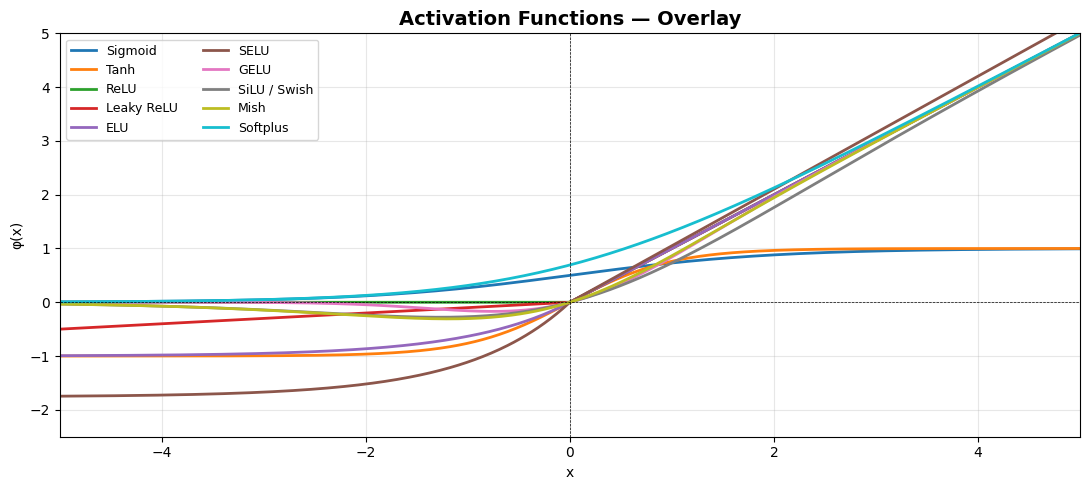

/tmp/ipykernel_16671/2122922242.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


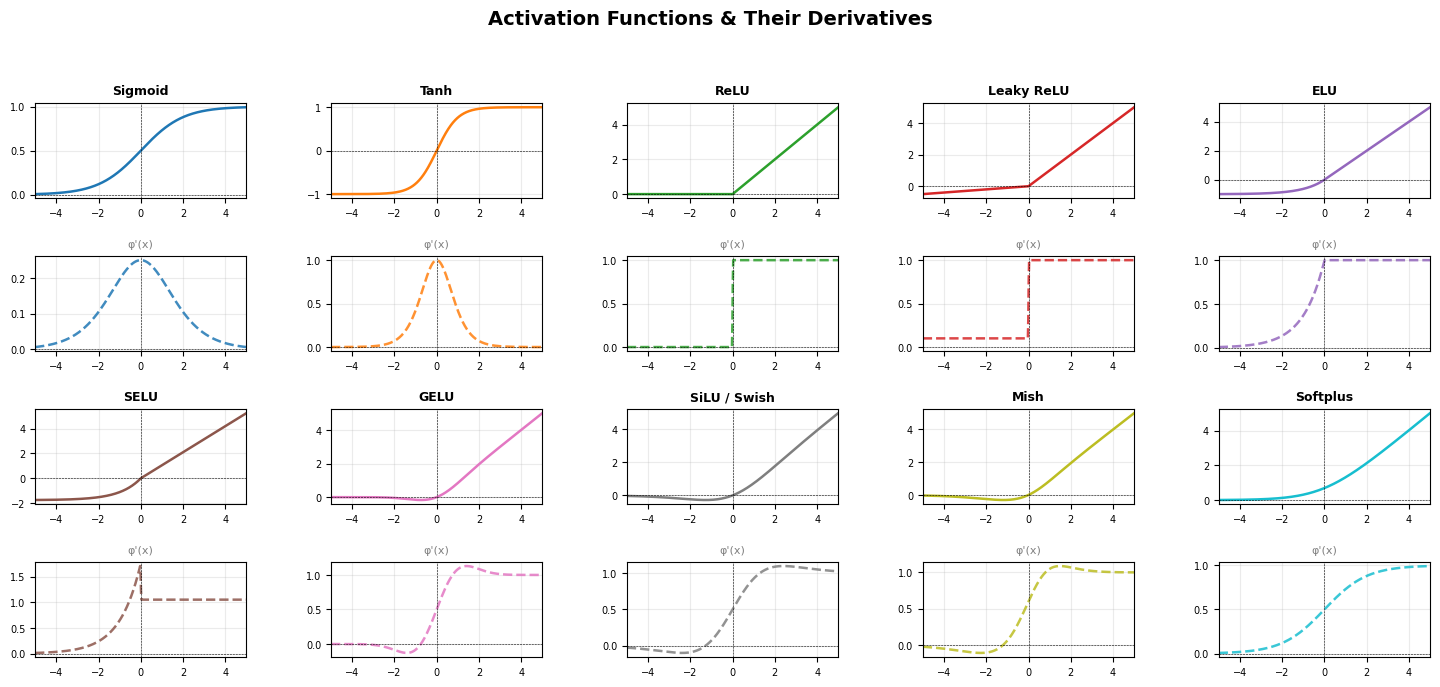

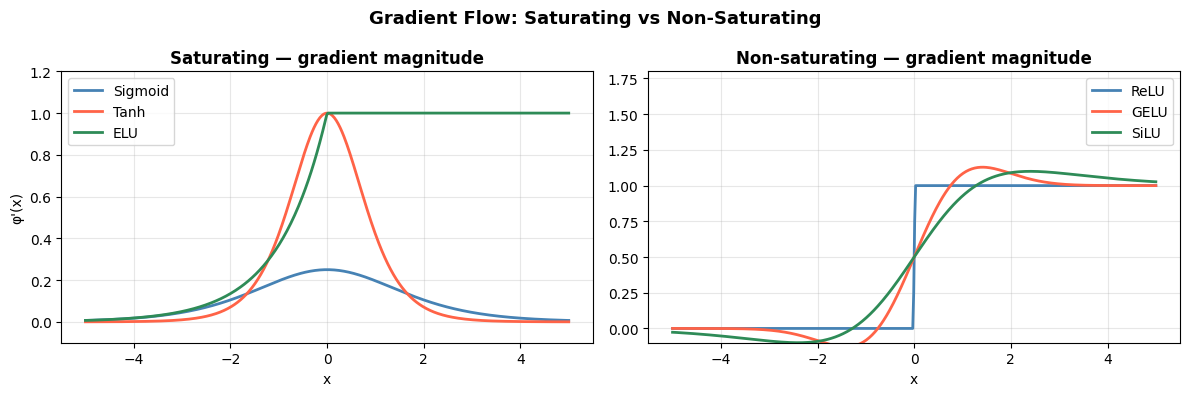

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import erf

x = np.linspace(-5, 5, 500)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def tanh(x):
    return np.tanh(x)


def relu(x):
    return np.maximum(0, x)


def leaky_relu(x, a=0.1):
    return np.where(x >= 0, x, a * x)


def elu(x, a=1.0):
    return np.where(x >= 0, x, a * (np.exp(x) - 1))


def selu(x):
    lam, a = 1.0507009873554805, 1.6732631921736981
    return lam * np.where(x >= 0, x, a * (np.exp(x) - 1))


def gelu(x):
    return x * 0.5 * (1 + erf(x / np.sqrt(2)))


def swish(x):
    return x * sigmoid(x)


def mish(x):
    return x * np.tanh(np.log1p(np.exp(x)))


def softplus(x):
    return np.log1p(np.exp(x))


activations = {
    "Sigmoid": sigmoid,
    "Tanh": tanh,
    "ReLU": relu,
    "Leaky ReLU": leaky_relu,
    "ELU": elu,
    "SELU": selu,
    "GELU": gelu,
    "SiLU / Swish": swish,
    "Mish": mish,
    "Softplus": softplus,
}

colors = plt.cm.tab10(np.linspace(0, 1, len(activations)))

# ── Figure 1: all activations overlaid ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
for (name, fn), c in zip(activations.items(), colors):
    ax.plot(x, fn(x), label=name, color=c, linewidth=2)
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
ax.axvline(0, color="k", linewidth=0.5, linestyle="--")
ax.set_xlim(-5, 5)
ax.set_ylim(-2.5, 5)
ax.set_title("Activation Functions — Overlay", fontsize=14, fontweight="bold")
ax.set_xlabel("x")
ax.set_ylabel("φ(x)")
ax.legend(ncol=2, fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Figure 2: individual plots with derivatives ───────────────────────────────
n = len(activations)
cols = 5
rows = (n + cols - 1) // cols * 2  # two rows per activation (fn + grad)
fig = plt.figure(figsize=(18, rows * 1.8))
gs = gridspec.GridSpec(rows, cols, hspace=0.6, wspace=0.4)

dx = x[1] - x[0]
for i, ((name, fn), c) in enumerate(zip(activations.items(), colors)):
    col = i % cols
    row = (i // cols) * 2

    y = fn(x)
    grad = np.gradient(y, dx)

    # activation
    ax1 = fig.add_subplot(gs[row, col])
    ax1.plot(x, y, color=c, linewidth=1.8)
    ax1.axhline(0, color="k", linewidth=0.4, linestyle="--")
    ax1.axvline(0, color="k", linewidth=0.4, linestyle="--")
    ax1.set_title(name, fontsize=9, fontweight="bold")
    ax1.set_xlim(-5, 5)
    ax1.tick_params(labelsize=7)
    ax1.grid(True, alpha=0.25)

    # derivative
    ax2 = fig.add_subplot(gs[row + 1, col])
    ax2.plot(x, grad, color=c, linewidth=1.8, linestyle="--", alpha=0.85)
    ax2.axhline(0, color="k", linewidth=0.4, linestyle="--")
    ax2.axvline(0, color="k", linewidth=0.4, linestyle="--")
    ax2.set_title(f"φ'(x)", fontsize=8, color="gray")
    ax2.set_xlim(-5, 5)
    ax2.tick_params(labelsize=7)
    ax2.grid(True, alpha=0.25)

fig.suptitle(
    "Activation Functions & Their Derivatives", fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

# ── Figure 3: saturation / gradient flow comparison ──────────────────────────
saturating = {"Sigmoid": sigmoid, "Tanh": tanh, "ELU": elu}
non_sat = {"ReLU": relu, "GELU": gelu, "SiLU": swish}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for (name, fn), c in zip(saturating.items(), ["steelblue", "tomato", "seagreen"]):
    axes[0].plot(x, np.gradient(fn(x), dx), label=name, linewidth=2, color=c)
axes[0].set_title("Saturating — gradient magnitude", fontweight="bold")
axes[0].set_ylim(-0.1, 1.2)
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlabel("x")
axes[0].set_ylabel("φ'(x)")

for (name, fn), c in zip(non_sat.items(), ["steelblue", "tomato", "seagreen"]):
    axes[1].plot(x, np.gradient(fn(x), dx), label=name, linewidth=2, color=c)
axes[1].set_title("Non-saturating — gradient magnitude", fontweight="bold")
axes[1].set_ylim(-0.1, 1.8)
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlabel("x")

plt.suptitle(
    "Gradient Flow: Saturating vs Non-Saturating", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()